In [1]:
import numpy as np
import pandas as pd
import nibabel as nb
import nitools as nt
import SUITPy as suit
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.summarize as cs
import Functional_Fusion.atlas_map as am
import matplotlib.pyplot as plt

/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


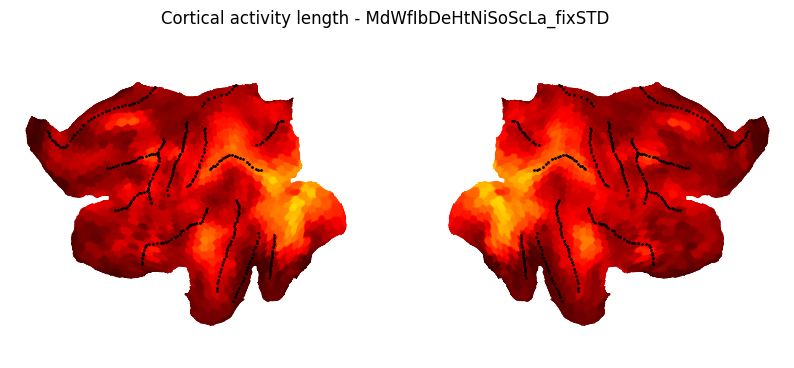

Mean activity length: 2.0900672377686975


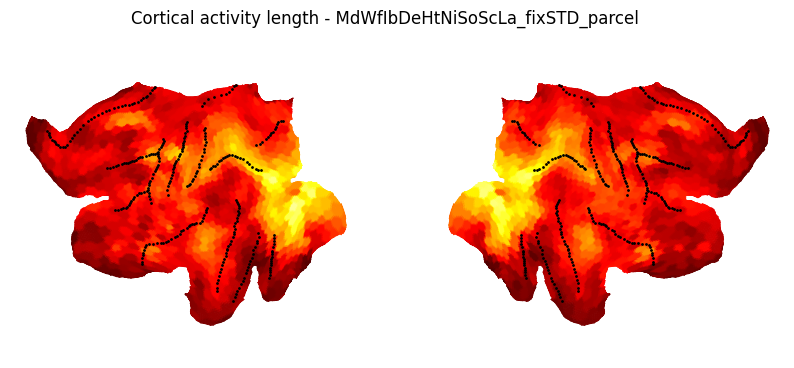

Mean activity length: 2.788968897540001


In [2]:
traindatas = ['MdWfIbDeHtNiSoScLa_fixSTD', 'MdWfIbDeHtNiSoScLa_fixSTD_parcel']

for traindata in traindatas:
    cifti_img = nb.load(gl.conn_dir + f'/maps/{traindata}_cortex.pscalar.nii')
    avrg_data= nt.surf_from_cifti(cifti_img)
    data_length = [np.sum(a**2,axis=0) for a in avrg_data]
    fig, axes = plt.subplots(1, 2,figsize=(10, 4))
    cs.plot_cortical_flatmap(data=data_length,axes = axes, cscale=[0,7],cmap='hot')
    plt.suptitle(f'Cortical activity length - {traindata}')
    plt.show()

    print(f'Mean activity length: {np.nanmean(data_length)}')

Overall length: 2.0607263978074464


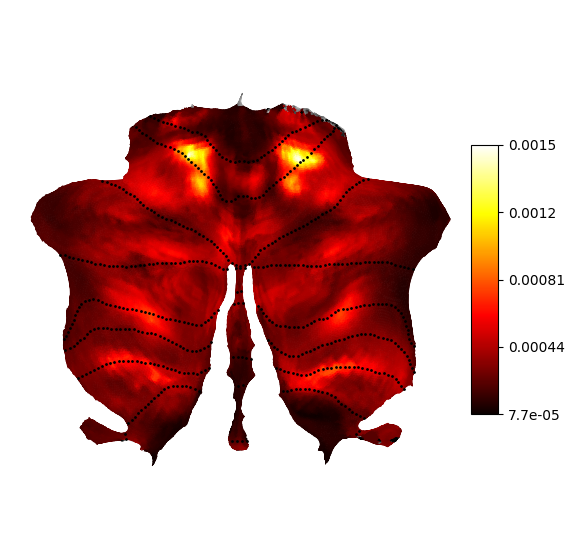

In [9]:
traindata = 'MdWfIbDeHtNiSoScLa_fixSTD'
atlas,ainf = am.get_atlas('MNISymC3')
cereb_data = nb.load(gl.conn_dir + f'/maps/{traindata}_cerebellum.dscalar.nii').get_fdata()
data_length = np.nansum(cereb_data**2, axis=0)

nifti_image = atlas.data_to_nifti(data_length)
data = suit.vol_to_surf(nifti_image, space='MNISymC')

print(f'Overall length: {np.nansum(data_length)}')
suit.flatmap.plot(data, cmap='hot', colorbar=True);